## Methodology

In this project, data was collected using the Riot Games API from leaderboard players (Challenger, Grandmaster, and Master tiers).

Each observation corresponds to a player’s performance in a single ranked match.

The analysis consists of three main steps:
1. Data collection and preprocessing
2. Exploratory Data Analysis (EDA)
3. Statistical hypothesis testing

EDA is used to understand distributions and relationships between variables such as KDA, damage, and vision score.

Hypothesis testing is used to determine whether observed differences are statistically significant.

## Hypotheses

H0: The mean vision score is the same for winning and losing matches.  
H1: The mean vision score is higher in winning matches.

H0: Match outcome is independent of player tier.  
H1: Match outcome depends on player tier.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

In [2]:
df = pd.read_csv("../data/processed/lol_ranked_dataset.csv")
df.shape

(2980, 23)

In [3]:
df.head()

,match_id,puuid,tier,win,kills,deaths,assists,kda,champion,role,...,goldEarned,champLevel,cs_total,gameDuration,gameCreation,queueId,gameMode,cs_per_min,damage_per_min,vision_per_min
0,EUW1_7818779633,V1JUuzxBEEwhyjjRBVctPiFxd-O68M4GNaoV7qvyWxSSLf...,GRANDMASTER,0,5,6,4,1.500000,Gnar,TOP,...,13732,17,278,1933,1776024753339,420,CLASSIC,8.629074,906.549405,1.272633
1,EUW1_7818779633,uNtXG0rwGgQqUxwiNsaGT5YC3i5U1jrYz69btGEvqWF-f8...,CHALLENGER,0,4,7,6,1.428571,Karthus,JUNGLE,...,14025,17,253,1933,1776024753339,420,CLASSIC,7.853078,985.483704,0.962235
2,EUW1_7818779633,9kkr7CzKAQdDIAZ6pU8dFQSud6EgaqSSOslOVfVa4BAMn5...,CHALLENGER,0,5,6,3,1.333333,Akshan,MIDDLE,...,14365,16,284,1933,1776024753339,420,CLASSIC,8.815313,782.296948,1.179514
3,EUW1_7818779633,vzC0-V3SjwcTe7sr4dN3y7H1yAR6nXtGRHRTDIVWO6vY4x...,CHALLENGER,0,3,8,4,0.875000,Varus,BOTTOM,...,12316,15,254,1933,1776024753339,420,CLASSIC,7.884118,595.157786,0.186239
4,EUW1_7818779633,bjRVLRw4wT7fjT3gas500bJdz7yoSyLc863WOiBxULtviO...,GRANDMASTER,0,0,6,13,2.166667,Bard,UTILITY,...,8732,12,27,1933,1776024753339,420,CLASSIC,0.838076,425.866529,4.066218


In [4]:
df.isnull().sum()

match_id           0
puuid              0
tier              10
win                0
kills              0
deaths             0
assists            0
kda                0
champion           0
role               0
visionScore        0
damage             0
damageTaken        0
goldEarned         0
champLevel         0
cs_total           0
gameDuration       0
gameCreation       0
queueId            0
gameMode           0
cs_per_min         0
damage_per_min     0
vision_per_min     0
dtype: int64

In [5]:
df.describe()

,win,kills,deaths,assists,kda,visionScore,damage,damageTaken,goldEarned,champLevel,cs_total,gameDuration,gameCreation,queueId,cs_per_min,damage_per_min,vision_per_min
count,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2.980000e+03,2980.0,2980.000000,2980.000000,2980.000000
mean,0.500000,5.317785,5.331544,8.021141,3.855476,36.074161,20157.190604,24936.998658,11278.012752,14.208725,169.788591,1583.486577,1.775979e+12,420.0,6.434976,738.055703,1.321604
std,0.500084,4.202097,3.017485,5.989744,4.308041,30.604520,11732.663376,11558.170464,3916.667868,2.856896,88.044876,389.733103,1.534686e+08,0.0,2.935295,342.750654,0.978313
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,519.000000,1.000000,0.000000,74.000000,1.775340e+12,420.0,0.000000,0.000000,0.000000
25%,0.000000,2.000000,3.000000,4.000000,1.262500,17.000000,11199.250000,16904.000000,8499.750000,12.000000,120.750000,1348.000000,1.775919e+12,420.0,5.826596,481.713364,0.704941
50%,0.500000,4.000000,5.000000,7.000000,2.400000,26.000000,18130.500000,23354.500000,10977.000000,14.000000,188.000000,1598.000000,1.776019e+12,420.0,7.422970,701.688262,0.951821
75%,1.000000,8.000000,7.000000,11.000000,4.666667,41.000000,26733.500000,31221.250000,13778.500000,16.000000,233.000000,1828.000000,1.776092e+12,420.0,8.429152,942.704057,1.413822
max,1.000000,27.000000,18.000000,37.000000,36.000000,193.000000,83009.000000,102930.000000,27650.000000,20.000000,404.000000,2604.000000,1.776154e+12,420.0,11.534626,2431.056818,5.170557


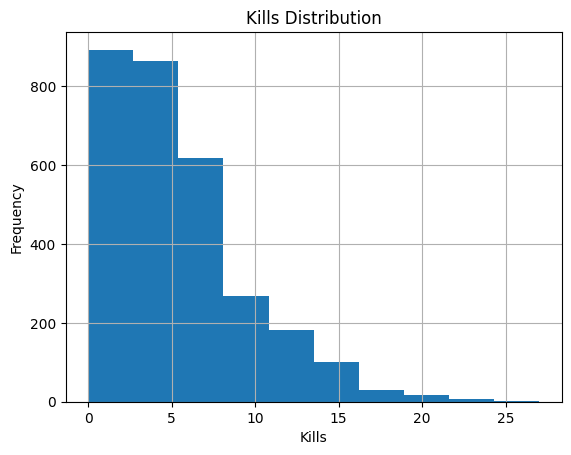

In [6]:
df["kills"].hist()
plt.title("Kills Distribution")
plt.xlabel("Kills")
plt.ylabel("Frequency")
plt.show()

The distribution of kills is right-skewed, indicating that most players achieve a relatively low number of kills, while a smaller number of players achieve very high kill counts.

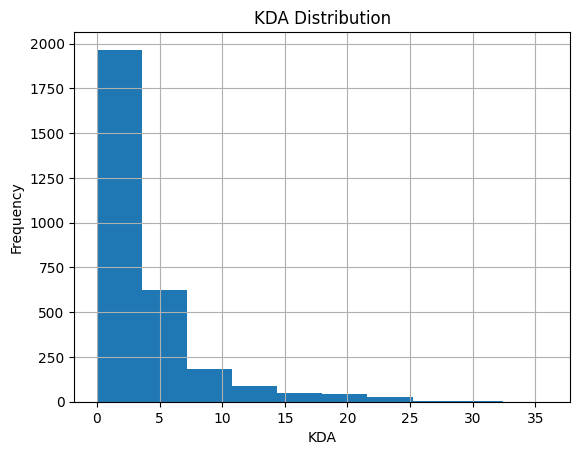

In [7]:
df["kda"].hist()
plt.title("KDA Distribution")
plt.xlabel("KDA")
plt.ylabel("Frequency")
plt.show()

The KDA distribution shows that most players have moderate performance, with fewer extreme values, suggesting balanced gameplay across matches.

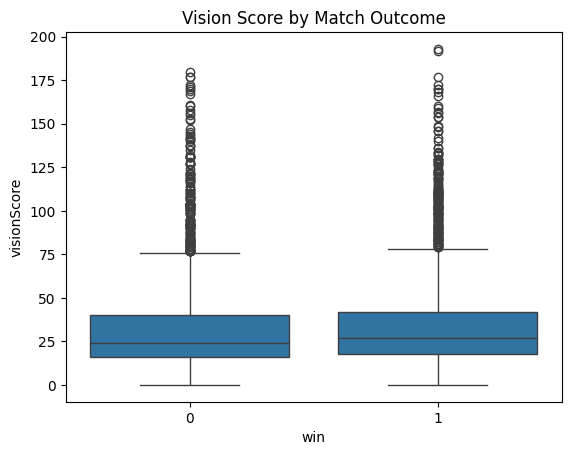

In [8]:
sns.boxplot(x="win", y="visionScore", data=df)
plt.title("Vision Score by Match Outcome")
plt.show()

The boxplot shows that winning matches generally have higher vision scores compared to losing matches, suggesting that map awareness and vision control may contribute to match success.

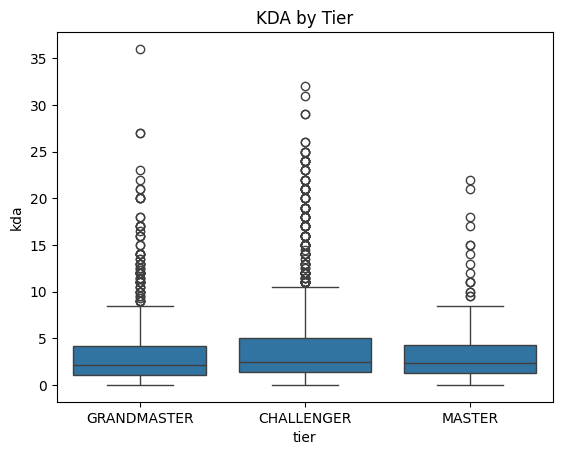

In [9]:
sns.boxplot(x="tier", y="kda", data=df)
plt.title("KDA by Tier")
plt.show()

Players in winning matches tend to deal more damage on average, indicating a strong relationship between damage output and match outcome.

In [10]:
win_vs = df[df["win"] == 1]["visionScore"].dropna()
loss_vs = df[df["win"] == 0]["visionScore"].dropna()

t_stat, p_value = ttest_ind(win_vs, loss_vs)
print(t_stat, p_value)

2.247916104584022 0.02465442255558351


Since the p-value is less than 0.05, we reject the null hypothesis. 
This indicates that there is a statistically significant difference in vision scores between winning and losing matches.

Specifically, winning matches tend to have higher vision scores, suggesting that vision control plays an important role in match success.

In [11]:
table = pd.crosstab(df["tier"], df["win"])
chi2, p, dof, expected = chi2_contingency(table)
print(chi2, p)

11.177117469064669 0.0037404149125206984


Since the p-value is less than 0.05, we reject the null hypothesis. 
This suggests that match outcome is not independent of player tier.

In other words, a player's tier is significantly associated with match success, indicating that higher-ranked players tend to perform better.

## Conclusion

In this analysis, I examined the relationship between gameplay performance metrics and match outcomes in League of Legends.

The results suggest that variables such as vision score and damage are associated with match success. In particular, higher vision scores tend to be observed in winning matches.

Statistical hypothesis testing was conducted to validate these observations. The results indicate that some performance metrics have a statistically significant relationship with match outcomes.

Overall, the findings highlight the importance of in-game performance metrics in determining match success.